# พฤติกรรมแบบสุ่มของสินทรัพย์

สมุดบันทึกประกอบบทเรียน เริ่มจากแนวคิดเรื่องความน่าจะเป็นของราคา พื้นฐาน Option และ payoff แล้วศึกษาผลตอบแทน ความผันผวน และ Wiener process แหล่งอ้างอิงอยู่ท้าย Notebook

ใช้ Python 3, NumPy และ Jupyter/IPython แล้วเลือก **Run All** ข้อมูล Perez Companc จากตารางรูป 3.3 ฝังอยู่ใน Notebook จึงไม่ต้องดาวน์โหลดข้อมูลตลาดหรือไฟล์ประกอบ ตัวเลขที่รายงานสำหรับอนุกรมเต็มในหนังสือแยกจากสถิติของตารางย่อย 34 ราคาอย่างชัดเจน

โค้ด SVG วาดภาพจากตัวเลขโดยตรง ป้ายกราฟใช้ภาษาอังกฤษเพื่อให้อ่านได้แม้เครื่องไม่มีฟอนต์ไทย หน้าเว็บและ NumPy ใช้ตัวสร้างเลขสุ่มต่างกัน จึงได้เส้นต่างกันแม้ใช้ seed เท่ากัน แต่รันซ้ำในแต่ละสภาพแวดล้อมได้

In [1]:
import numpy as np
from html import escape
from IPython.display import display, SVG
print("NumPy", np.__version__)

def chart(series, title, x_label, y_label, y_limits=None):
    """Each series has x, y, label, color and optional bar_width."""
    W, H, L, R, T, B = 780, 400, 70, 25, 75, 55
    xmin = min(float(np.min(s["x"])) for s in series)
    xmax = max(float(np.max(s["x"])) + s.get("bar_width", 0) for s in series)
    finite = np.concatenate([np.asarray(s["y"])[np.isfinite(s["y"])] for s in series])
    if y_limits is None:
        lo, hi = min(0, float(finite.min())), max(0, float(finite.max()))
        margin = max((hi-lo)*.08, .001)
        lo, hi = lo-margin, hi+margin
    else:
        lo, hi = y_limits
    xx = lambda v: L+(v-xmin)/max(xmax-xmin, 1e-12)*(W-L-R)
    yy = lambda v: T+(hi-v)/(hi-lo)*(H-T-B)
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{W}" height="{H}" viewBox="0 0 {W} {H}" role="img"><title>{escape(title)}</title>', '<rect width="100%" height="100%" fill="white"/>', '<g font-family="sans-serif" font-size="12" fill="#414141">', f'<text x="{L}" y="23" font-size="16">{escape(title)}</text>', f'<text x="{L}" y="62">{escape(y_label)}</text>']
    legend = 0
    for s in series:
        if s.get("label"):
            parts.append(f'<text x="{L+legend*225}" y="42" fill="{s["color"]}">{escape(s["label"])}</text>')
            legend += 1
    for value in np.linspace(lo, hi, 5):
        parts += [f'<line x1="{L}" x2="{W-R}" y1="{yy(value)}" y2="{yy(value)}" stroke="#ddd"/>', f'<text x="{L-8}" y="{yy(value)+4}" text-anchor="end">{value:.3g}</text>']
    for value in np.linspace(xmin, xmax, 5):
        parts.append(f'<text x="{xx(value)}" y="{H-B+23}" text-anchor="middle">{value:.3g}</text>')
    for s in series:
        if "bar_width" in s:
            for x,y in zip(s["x"], s["y"]):
                parts.append(f'<rect x="{xx(x)}" y="{min(yy(0),yy(y))}" width="{xx(x+s["bar_width"])-xx(x)}" height="{abs(yy(y)-yy(0))}" fill="{s["color"]}" fill-opacity=".45" stroke="white"/>')
        else:
            points = ' '.join(f'{xx(x):.2f},{yy(y):.2f}' for x,y in zip(s["x"],s["y"]) if np.isfinite(y))
            parts.append(f'<polyline points="{points}" fill="none" stroke="{s["color"]}" stroke-width="{s.get("stroke",2)}"/>')
    parts += [f'<text x="{W-R}" y="{H-7}" text-anchor="end">{escape(x_label)}</text>', '</g></svg>']
    return SVG(''.join(parts))


NumPy 2.0.2


# พฤติกรรมแบบสุ่มของสินทรัพย์

The Random Behavior of Assets

> “ปัจจัยที่กำหนดการเคลื่อนไหวของตลาดหุ้นมีมากมายนับไม่ถ้วน”
>
> “Les influences qui déterminent les mouvements de la Bourse sont innombrables…”
>
> — **Louis Bachelier** · [*Théorie de la spéculation (1900), น. 21*](https://www.numdam.org/item/ASENS_1900_3_17__21_0.pdf#page=2)

> “มีคนเพียง สองประเภทที่ บอกว่าเขาสามารถทำนาย ทิศทางราคาได้ ........... คือคนเสียสติ และ คนโกหก”

เรากำลังมาถึงสิ่งที่าำคัญที่สุดของ Quant นั้นคือการเข้าใจตลาดกหารเงินว่ามันสุ่มมมมมมม ผมอยากเริ่มต้นที่คำถาม อะไรบ้างที่ส่งผลต่อราคาหุ้น
.

.

.

.

.

.

.

ข่าวที่เพิ่งออก ผลประกอบการที่ประกาศไปแล้ว สิ่งที่คนคาดว่าจะเกิดในอนาคต รวมถึงการซื้อขายของคนอื่น ทั้งหมดเข้ามารวมอยู่ในราคา บางเรื่องดูเหมือนไม่เกี่ยวกับหุ้นตัวนั้นเลย แต่สุดท้ายก็ส่งผลถึงกันได้ 

ที่สำคัญ ตลาดยังตอบสนองต่อการเคลื่อนไหวของตัวเองด้วย ราคาที่เปลี่ยนไปทำให้คนเปลี่ยนใจ แล้วการตัดสินใจรอบใหม่ก็กลับมาเปลี่ยนราคาอีกที ในทุก คำสั่งที่ถูกซื้อขายมีทั้งคนซื้อและคนขาย เราเห็นราคาเดียวกันได้ แต่มีความคาดหวัง เหตุผล และข้อจำกัดต่างกัน การจะรวบรวมทุกปัจจัยเพื่อบอกล่วงหน้าว่าราคาต้องไปอยู่ตรงไหนจึงเป็นโจทย์ที่เป็นไปไม่ได้ 

และนี้คือแนวคิดหลักของ **Louis Bachelier** ในงานปริญาเอกที่ถูกลืมอย่าง *Théorie de la spéculation* เมื่อปี **1900** จากแนวคิดนี้ เราถามต่อได้ว่า ถ้าเราไม่รู้ว่าราคาจะเคลื่อนไปทางไหนแน่ ๆ เราจะอธิบายได้ไหมว่า การเคลื่อนไหวแต่ละแบบมีโอกาสเกิดมากน้อยแค่ไหน? [อ่านงานต้นฉบับของ Bachelier](https://www.numdam.org/item/ASENS_1900_3_17__21_0/) แล้วถ้าราคาไม่แน่นอนเราจะทำแบบจำลองบนมันได้อย่างไร โชคดีของพวกเราที่ บาเซลิเย่ตอบคำถามพวดนั้นหมดแล้ว

**การใช้คณิตศาสตร์ศึกษาความเป็นไปได้ของราคา คือหนึ่งในรากฐานสำคัญของ[การเงินเชิงปริมาณ หรือ Quant](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#quantitative-finance)** งานของ Bachelier เป็นหมุดหมายแรก ๆ ของการนำความน่าจะเป็นมาศึกษาราคา แนวคิดนี้ยังต้องอาศัยสมมติฐานและการตรวจสอบกับข้อมูล เราไม่สามารถทำนายราคาแต่เราสร้างโมเดลได้

สำหรับบทนี้ ผมจะพาทุกคนมาเข้าใจหลักการสำคัญก่อนมากกว่า  **Bug World** หรือเครื่องมือสำเร็จรูป  แล้วค่อยต่อยอดไปสู่แบบจำลองราคาที่มีทั้งการเปลี่ยนแปลงเฉลี่ยและส่วนสุ่ม

**เนื้อหาในบทนี้**

พื้นฐาน Option และ payoff · Jensen’s inequality · ผลตอบแทน · ค่าเฉลี่ยและความผันผวน · Wiener process · แบบจำลองราคาสินทรัพย์ในเวลาต่อเนื่อง

ศัพท์ที่ขีดเส้นใต้แบบจุดกดอ่านความหมายได้ใน [อภิธานศัพท์](glossary.html)

## บทนำ

ในบทนี้จะสร้างแบบจำลองแรกของการเงิน เพื่อให้เข้าใจพฤติกรรมการสุ่มนี้ กล่าวคือ ผลที่เกิดขึ้นในแต่ละครั้งไม่แน่นอน แต่เรายังสามารถอธิบายกฎความน่าจะเป็นของมัน และศึกษาผลสะสมเมื่อทำซ้ำหลายครั้งได้

จากจุดนี้เราจะเข้าสู่เรื่อง [stochastic calculus](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#stochastic-calculus) หรือแคลคูลัสของกระบวนการสุ่ม (เราไม่ได้จะพาไปสมการยากๆ stochastic = สุ่ม , แคลคูลัส คือการศึกษาการเปลี่ยนแปลงและการรวมกัน  ) และ [Wiener process](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#wiener-process) แม้เบื้องหลังแนวคิดเหล่านี้จะมีทฤษฎีอยู่มาก แต่เป้าหมายของบทคือสร้างความเข้าใจต่อแบบจำลองก่อน รายละเอียดทางคณิตศาสตร์จะตามมาในบทถัดไป (ถ้าผมยังเขียนต่อนะ )

## แนวทางการวิเคราะห์ที่นิยมใช้

ก่อนจะไปต่อ ผมอยากชวนดูว่าเวลาคนพูดว่า “วิเคราะห์หุ้น” เขากำลังวิเคราะห์อะไรกันอยู่ เรามักได้ยินอยู่สามคำคือ [Fundamental](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#fundamental-analysis), [Technical](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#technical-analysis) และ [Quant](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#quantitative-analysis) แต่ละแบบเริ่มจากคนละคำถาม และในงานจริงก็ใช้ร่วมกันได้

### การวิเคราะห์ปัจจัยพื้นฐาน — Fundamental analysis

ถ้าเรามองหุ้นเป็นส่วนหนึ่งของธุรกิจ คำถามแรกก็คือ ธุรกิจนี้ควรมีมูลค่าเท่าไร? เราจึงต้องดูว่าบริษัทหาเงินจากอะไร รายได้โตได้อีกไหม ต้นทุนกับหนี้เป็นอย่างไร และอะไรทำให้ลูกค้ายังเลือกซื้อของจากบริษัทนี้

ลองสมมติว่าเราประเมินหุ้นตัวหนึ่งไว้ที่ 80 บาท แต่ตลาดซื้อขายกันอยู่ที่ 60 บาท ดูเหมือนมีส่วนต่างให้เราแล้วใช่ไหม? ปัญหาคือ 80 บาทนั้นยังเป็นผลจากสมมติฐานของเรา ถ้ายอดขายไม่โตตามที่คิด หรือบริษัทต้องลงทุนมากกว่าที่คาด มูลค่าที่คำนวณได้ก็เปลี่ยน และอย่างที่บอกว่า ปัจจัยกำหนดราคาหุ้นมีมากมายนับอนัน

อีกเรื่องคือ ต่อให้เราประเมินถูก ราคาก็อาจอยู่ที่ 60 บาทต่อไปอีกนาน การตอบว่า “ควรมีมูลค่าเท่าไร” กับ “เมื่อไรตลาดจะให้ราคานั้น” จึงเป็นคนละโจทย์ เราต้องคิดเรื่องเวลาที่รอได้และความเสี่ยงระหว่างทางด้วย

### การวิเคราะห์ทางเทคนิค — Technical analysis

แนวทางนี้เริ่มจากสิ่งที่เกิดขึ้นในตลาดแล้ว เช่น ราคา ปริมาณซื้อขาย และรูปแบบการเคลื่อนไหว เราอาจดูว่าราคากำลังเป็นแนวโน้ม เคลื่อนไหวในกรอบ หรือเปลี่ยนพฤติกรรมไปจากช่วงก่อนหน้า

แต่ปัญหาหลักคือ เทคนิคอลทั้งหมด มักจะไม่มีกฏที่แน่นอน แม้กระทั้งนักวิเคราะที่เก่งที่สุด สองคนอาจจะมองต่างกัน 

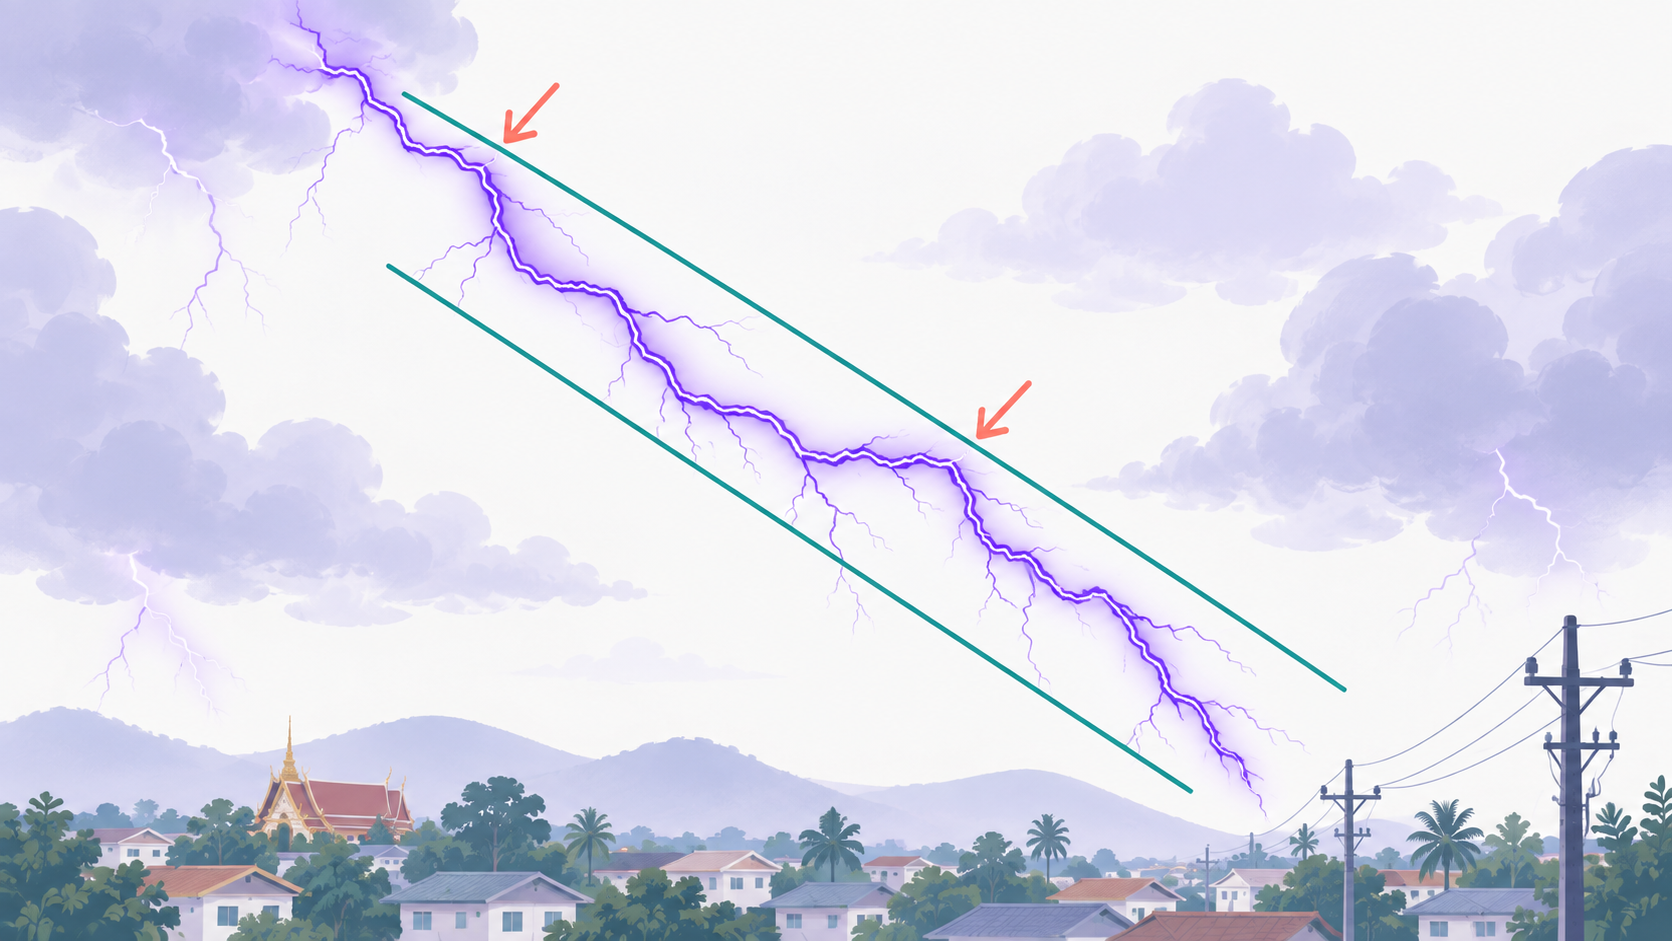

*“แนวรับแข็งมาก… เสาไฟยังอยู่” — มุกขำ ๆ ของการเห็นรูปแบบในทุกอย่าง ลากเส้นให้เข้ากับสิ่งที่เกิดขึ้นแล้วอาจทำได้ง่าย แต่จะใช้คาดการณ์สิ่งที่ยังไม่เกิดได้จริงไหม ต้องทดสอบกันอีกเรื่อง*

### การวิเคราะห์เชิงปริมาณ — Quantitative analysis

สำหรับ Quant ถ้าให้ผมนิยามความหมาย คงหมายถึงศาตร์ที่ศึกษา พลวัตร์(สุ่ม)ของตราสารทางการเงิน เราพยายามทำคำถามให้ชัดพอที่จะวัดและตรวจสอบได้ ใช้ข้อมูล คณิตศาสตร์ และสถิติมาสร้างแบบจำลอง แล้วดูว่าคำตอบเปลี่ยนอย่างไรเมื่อสมมติฐานเปลี่ยน

ตัวอย่างเช่น ถ้าพอร์ตหนึ่งมีโอกาสขาดทุน เราจะประมาณขนาดของการขาดทุนนั้นอย่างไร? ถ้าสินทรัพย์หลายตัวตกพร้อมกัน ความเสี่ยงรวมจะเพิ่มแค่ไหน? หรือถ้าสัญญาจะจ่ายเงินตามราคาหุ้นในอนาคต วันนี้เราควรประเมินมูลค่าของสิทธินั้นอย่างไร?

ในบทนี้เราจะเริ่มจาก **แบบจำลองความสุ่มของราคา** และเราจะเข้าใจ หลักการของ Quant ผ่านตราสารทางการเงินที่เรียกว่า Option

## เข้าใจ Quant ผ่าน Option

[Option](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#option) คือสัญญาที่ให้ผู้ถือมี **สิทธิ แต่ไม่มีข้อผูกมัดว่าต้องใช้สิทธิ** ในการซื้อหรือขายสินทรัพย์ตามราคาและเงื่อนไขที่ตกลงกัน สิทธิซื้อเรียกว่า **[Call option](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#call-option)** ส่วนสิทธิขายเรียกว่า **[Put option](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#put-option)** ผู้ซื้อจ่ายเงินเพื่อให้ได้สิทธินี้ เงินนั้นเรียกว่า **[premium](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#premium)** หรือราคาออปชัน

ลองเริ่มจาก Call ก่อน สมมติว่าเรามีสิทธิซื้อหุ้นหนึ่งหน่วยในราคา **120 บาท** เมื่อครบหนึ่งเดือน โดยจ่ายค่าซื้อสิทธินี้ไป **8 บาท** ราคา 120 บาทเรียกว่า **[ราคาใช้สิทธิ (strike price)](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#strike-price)** และวันที่ครบหนึ่งเดือนคือ **[วันหมดอายุ (expiration)](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#maturity)** ตัวอย่างนี้กำหนดให้ใช้สิทธิได้ในวันหมดอายุเท่านั้น หรือที่เรียกว่า [European option](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#european-option)

ถ้าวันนั้นหุ้นมีราคา 160 บาท สิทธิซื้อที่ 120 บาทก็มีมูลค่า 40 บาท แต่ถ้าหุ้นเหลือ 90 บาท เราก็ไม่จำเป็นต้องใช้สิทธิซื้อแพงกว่าตลาด สิทธินั้นจึงมี [payoff](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#payoff) เป็นศูนย์ ส่วนผู้ขาย Option มีหน้าที่ทำตามสัญญาเมื่อมีการใช้สิทธิ

| ราคาหุ้นวันหมดอายุ | Payoff ของ Call ต่อหนึ่งหน่วย | กำไร/ขาดทุนหลังหัก premium 8 บาท |
|---|---:|---:|
| 160 บาท | 40 บาท | 32 บาท |
| 120 บาท | 0 บาท | −8 บาท |
| 90 บาท | 0 บาท | −8 บาท |

ตัวอย่างนี้ยังไม่รวมค่าธรรมเนียมและมูลค่าของเงินตามเวลา **payoff ไม่ใช่กำไรสุทธิ** และไม่ใช่ราคา Option ที่เราจ่ายวันนี้ แม้เราเลือกไม่ใช้สิทธิ เงิน 8 บาทที่จ่ายไปก็ไม่ได้คืน

ถ้าเขียนเป็นสูตร ให้ S_T เป็นราคาหุ้นวันหมดอายุ และให้ K เป็นราคาใช้สิทธิ จะได้ payoff ของ Call ต่อหนึ่งหน่วยเท่ากับ **max(S_T − K, 0)** กล่าวคือ รับส่วนต่างเมื่อราคาหุ้นสูงกว่า K และเป็นศูนย์เมื่อราคาไม่สูงกว่า K

ตรงนี้แหละที่เชื่อมไปสู่การกำหนดราคา Option: ตอนนี้เรารู้แล้วว่าจะคำนวณ payoff อย่างไรเมื่อถึงวันหมดอายุ แต่ **วันนี้ควรจ่ายเท่าไรเพื่อซื้อสิทธินั้น**? จำนวน 8 บาทข้างต้นเป็นเพียงราคาที่สมมติขึ้น ยังไม่ได้พิสูจน์ว่าเป็นราคาที่เหมาะสม เราต้องพิจารณาผลลัพธ์ที่อาจเกิดขึ้นและวิธีประเมินมูลค่าของมันก่อน

## เหตุใดจึงต้องจำลองความสุ่ม: Jensen’s inequality

เมื่อรู้จัก payoff แล้ว ลองกลับมาตั้งคำถามเรื่องราคา: ถ้าเราประมาณราคาหุ้นเฉลี่ยในอนาคตได้ ทำไมไม่เอาราคาเฉลี่ยนั้นไปแทนในสูตร Call แล้วคิดลดกลับมาเป็นราคาวันนี้เลย? ลองดูตัวอย่างต่อไปนี้ แล้วเราจะเห็นว่าข้อมูลอะไรหายไปเมื่อเฉลี่ยเร็วเกินไป

ให้ราคาหุ้นวันนี้เท่ากับ **100 ดอลลาร์** อีกหนึ่งปีมีสองกรณี: ขึ้นเป็น **150 ดอลลาร์ ด้วยโอกาส 0.6** หรือลงเป็น **50 ดอลลาร์ ด้วยโอกาส 0.4** ตัวเลขนี้เป็น[ความน่าจะเป็นในโลกจริง](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#physical-probability)ที่เราสมมติขึ้น เรียกว่า p ส่วน Call มีราคาใช้สิทธิ 100 ดอลลาร์และหมดอายุในอีกหนึ่งปี

ถ้าเฉลี่ยราคาก่อน เราจะได้ 0.6 × 150 + 0.4 × 50 = **110 ดอลลาร์** เมื่อนำไปแทนในสูตร Call จะได้ max(110 − 100, 0) = **10 ดอลลาร์**

แต่ถ้าคำนวณ payoff แยกทีละกิ่ง ขาขึ้นจ่าย 50 และขาลงจ่าย 0 จากนั้นค่อยถ่วงน้ำหนัก จะได้ 0.6 × 50 + 0.4 × 0 = **30 ดอลลาร์** เฉลี่ยก่อนกับคำนวณ payoff ก่อนจึงให้คำตอบคนละค่า

$$
f\bigl(\mathbb{E}_P[S]\bigr)=10,
\qquad
\mathbb{E}_P[f(S)]=0.4(0)+0.6(50)=30.
$$

ลำดับของการคำนวณจึงสำคัญ **payoff ของราคาคาดหมาย ไม่จำเป็นต้องเท่ากับ[ค่าคาดหมาย](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#expected-value)ของ payoff** และ 30 ดอลลาร์นี้ยังเป็นเพียง payoff คาดหมายภายใต้ p ไม่ใช่ราคา Call วันนี้

ในทางคณิตศาสตร์ ตัวอย่างนี้เป็นกรณีหนึ่งของ [Jensen’s inequality](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#jensens-inequality) ถ้า f เป็นฟังก์ชันนูนของ[ตัวแปรสุ่ม](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#random-variable) S และค่าคาดหมายที่เกี่ยวข้องมีอยู่ จะได้ว่า

$$
\mathbb{E}[f(S)]\geq f\bigl(\mathbb{E}[S]\bigr).
\tag{3.1}
$$

Payoff ของ call คือ f(S) = max(S − K, 0) ซึ่งเป็นฟังก์ชันนูน ความนูนในที่นี้ไม่จำเป็นต้องเป็นเส้นโค้งเรียบ เส้นตรงสองช่วงที่หักมุมตรงราคาใช้สิทธิก็เป็นฟังก์ชันนูนได้

### การแจกแจงและความแปรปรวนเข้ามาเกี่ยวข้องกันอย่างไร

ลองขยายความสัมพันธ์นี้ด้วย Taylor expansion รอบค่าเฉลี่ย โดยกำหนดให้

$$
S=\bar S+\varepsilon,
\qquad \bar S=\mathbb{E}[S],
\qquad \mathbb{E}[\varepsilon]=0.
$$

ถ้าฟังก์ชันทำให้เราสเกลได้ เราเขียนโดยประมาณว่า

$$
\begin{aligned}
\mathbb{E}[f(S)]
&\approx f(\bar S)+f'(\bar S)\mathbb{E}[\varepsilon]
 +\tfrac12 f''(\bar S)\mathbb{E}[\varepsilon^2]\\
&=f\bigl(\mathbb{E}[S]\bigr)
 +\tfrac12 f''\bigl(\mathbb{E}[S]\bigr)\operatorname{Var}(S).
\end{aligned}
$$

เทอมอันดับหนึ่งหายไปเพราะ ε มีค่าเฉลี่ยศูนย์ ส่วนต่างที่เหลือจึงเชื่อมโยงกับสองสิ่ง ได้แก่ **ความนูนของฟังก์ชัน** ซึ่งสะท้อนผ่านอนุพันธ์อันดับสอง และ **[ความแปรปรวน](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#variance)ของสินทรัพย์อ้างอิง** ซึ่งวัดขนาดความไม่แน่นอน

นี่คือเหตุผลที่ความเข้าใจจากสัญญาเชิงเส้นอย่าง forward หรือ futures อาจนำมาใช้กับออปชันโดยตรงไม่ได้ สำหรับ payoff ที่ไม่เป็นเส้นตรง การรู้ค่าเฉลี่ยของสินทรัพย์อ้างอิงยังไม่พอ เราต้องรู้ลักษณะการกระจายของมันด้วย

Taylor expansion เป็นการประมาณสำหรับฟังก์ชันที่เรียบพอ ไม่ควรนำอนุพันธ์อันดับสองธรรมดาไปแทนตรงมุมของ payoff ของ Call ที่ราคาใช้สิทธิโดยตรง

E[S] = 110.00, E[f(S)] = 30.00, f(E[S]) = 10.00 USD


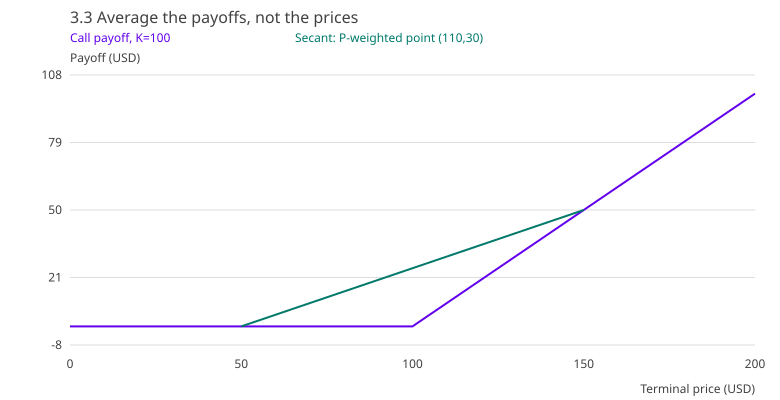

In [2]:
# ตัวอย่างปรับใหม่: p ขาลง 0.4, ขาขึ้น 0.6; risk-neutral q เมื่อ r=0
future, p, K = np.array([50., 150.]), np.array([.4, .6]), 100.
payoff = np.maximum(future-K, 0)
expected_price, expected_payoff = p@future, p@payoff
payoff_at_mean = max(expected_price-K, 0)
print(f"E[S] = {expected_price:.2f}, E[f(S)] = {expected_payoff:.2f}, f(E[S]) = {payoff_at_mean:.2f} USD")
assert expected_payoff == 30 and payoff_at_mean == 10
x = np.linspace(0, 200, 201)
display(chart([dict(x=x,y=np.maximum(x-K,0),label="Call payoff, K=100",color="#6200ee"), dict(x=future,y=payoff,label="Secant: P-weighted point (110,30)",color="#00796b")], "3.3 Average the payoffs, not the prices", "Terminal price (USD)", "Payoff (USD)"))


## ไม่ต้องทายถูกทุกครั้ง แล้วเราหาราคา Option ได้อย่างไร

เมื่อกี้เราเห็นแล้วว่าเฉลี่ย payoff กับคำนวณ payoff จากราคาเฉลี่ยให้คำตอบต่างกัน แต่ยังเหลือคำถามใหญ่: **แล้วราคา Option วันนี้ควรเป็นเท่าไร?** คราวนี้ลดโจทย์ให้เหลือแค่หนึ่งวัน จะได้เห็นเหตุผลทีละขั้น

หุ้นวันนี้ราคา 100 ดอลลาร์ พรุ่งนี้ขึ้นเป็น 101 ด้วยโอกาส 0.6 หรือลงเป็น 99 ด้วยโอกาส 0.4 เรามี European Call ที่ K = 100 และหมดอายุพรุ่งนี้ ให้ราคาที่ยังไม่รู้วันนี้เป็น V สมมติดอกเบี้ย 0% ไม่มีเงินปันผลและค่าธรรมเนียม ซื้อขายหุ้นเป็นเศษส่วน กู้ยืม และขายชอร์ตหุ้นหรือ Option ได้ตามต้องการ

### ความน่าจะเป็นไม่ส่งผลต่อราคา 

ถ้าหุ้นเป็น 101 เราใช้สิทธิได้ส่วนต่าง 1 ถ้าหุ้นเป็น 99 เราไม่ใช้สิทธิ จึงได้ 0 ดูเผิน ๆ เราอาจตอบว่า Call ควรมีราคา 0.6 × 1 + 0.4 × 0 = **0.6 ดอลลาร์** แต่ตัวเลขนี้เป็น payoff คาดหมายตาม p ที่สมมติไว้ 

ลองพักเรื่องทิศทางราคาไว้ก่อน แล้วถามใหม่ว่า **เราจัดพอร์ตให้ผลลัพธ์เหมือนกันทั้งขาขึ้นและขาลงได้ไหม?(Replicate)**

### ซื้อ Call หนึ่งหน่วย แล้วขายชอร์ตหุ้นครึ่งหุ้น

[การขายชอร์ต](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#short-selling)คือยืมหุ้นมาขายก่อน และมีภาระต้องซื้อกลับไปคืนภายหลัง ไม่ได้แปลว่ามีหุ้นติดลบโดยไม่มีภาระอะไร ถ้าเราถือ Call หนึ่งหน่วยกับสถานะชอร์ตหุ้นครึ่งหุ้น มูลค่าสุทธิของพอร์ตวันนี้คือ **V − ½ × 100 = V − 50**

พรุ่งนี้ลองคิดแยกทีละกิ่ง:

- หุ้นขึ้นเป็น 101: Call มีค่า 1 แต่ต้องซื้อหุ้นครึ่งหุ้นคืนในราคา 50.5 มูลค่าสุทธิจึงเป็น **1 − 50.5 = −49.5**
- หุ้นลงเป็น 99: Call มีค่า 0 และซื้อหุ้นครึ่งหุ้นคืนในราคา 49.5 มูลค่าสุทธิจึงเป็น **0 − 49.5 = −49.5**

**ราคาหุ้นยังไม่แน่นอน แต่ผลลัพธ์สุทธิของพอร์ตนี้แน่นอนแล้ว** เราเรียกการจัดพอร์ตเพื่อหักล้างความเสี่ยงแบบนี้ว่า [Hedging](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#hedging) เลขติดลบ −49.5 หมายถึงภาระสุทธิที่ต้องจ่ายเมื่อปิดสถานะพรุ่งนี้ ไม่ใช่กำไร และไม่ได้แปลว่าเราเพิ่งขาดทุน 49.5 เพราะต้องนับเงินรับจากการขายชอร์ตวันนี้ด้วย

### และถ้าคุณซืื้อ ที่ 0.6 Quant จึงทำกำไรจากคุณ

ภาระที่ต้องจ่าย 49.5 พรุ่งนี้ เมื่อดอกเบี้ยเป็นศูนย์ มีมูลค่าเป็นภาระ 49.5 วันนี้เช่นกัน ดังนั้น

$$
V-\tfrac12(100)=-49.5
\quad\Rightarrow\quad V=0.5.
$$

จะดูเป็นกระแสเงินสดก็ได้: ขายชอร์ตครึ่งหุ้นรับ 50 จ่ายซื้อ Call 0.5 เหลือ 49.5 เก็บเงินนี้ไว้ พรุ่งนี้เงินที่เก็บไว้พอดีกับภาระสุทธิ 49.5 ไม่ว่าหุ้นจะขึ้นหรือลง

แล้วทำไมราคาตลาดต้องยอมตาม 0.5? ภายใต้สมมติฐานนี้ ถ้า Call ขายที่ 0.6 เราขาย Call ซื้อหุ้นครึ่งหุ้น และกู้ 49.5 จะรับเงินสุทธิวันนี้ **0.6 − 50 + 49.5 = 0.1** ส่วนพรุ่งนี้หุ้นลบ payoff ที่ต้องจ่ายและหนี้รวมกันได้ศูนย์ทั้งสองกรณี ถ้า Call ขายที่ 0.4 ก็กลับด้าน: ซื้อ Call ชอร์ตครึ่งหุ้น และฝาก 49.5 รับสุทธิวันนี้ **−0.4 + 50 − 49.5 = 0.1** และปิดภาระพรุ่งนี้ได้ครบ นี่คือเหตุผลแบบ **[no arbitrage](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#no-arbitrage)** ที่บังคับให้ราคาเป็น 0.5 ในแบบจำลอง

### แล้วรู้ได้อย่างไรว่าต้องชอร์ตครึ่งหุ้น

เราเลือกจำนวนหุ้น h ให้ผลลัพธ์สองกิ่งเท่ากัน: 1 − 101h = 0 − 99h จึงได้ h = (1 − 0) ÷ (101 − 99) = **0.5** หรือเขียนทั่วไปว่า [hedge ratio](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#delta) เท่ากับ **ส่วนต่าง payoff ÷ ส่วนต่างราคาหุ้น**

ครึ่งหุ้นจึงเป็นสัดส่วนที่คำนวณได้ ไม่ใช่การเดา และไม่ใช่ค่าคงที่สำหรับทุก Option เราขยายขนาดเป็น Call สองหน่วยกับหุ้นหนึ่งหุ้นได้ แต่ต้องคำนึงถึงจำนวนหุ้นอ้างอิงต่อสัญญาจริงด้วย

บางกลยุทธ์ดูแปลกถ้ามองทีละรายการ ทำไมซื้อ Call แล้วกลับขายชอร์ตหุ้น? เพราะเราไม่ได้ถามแค่ว่า “ราคาจะขึ้นหรือลง” เราถามว่า **จะประกอบสถานะอย่างไรให้ได้ผลลัพธ์หรือความเสี่ยงที่ต้องการ** เหตุผลอยู่ที่ทั้งพอร์ต และต้องตรวจสอบออกมาเป็นตัวเลขได้

### p หายไปไหน แล้ว risk-neutral เข้ามาตอนไหน

สังเกตว่าตั้งแต่ทำให้สองกิ่งเท่ากันจนได้ V = 0.5 เราไม่ได้ใช้ p = 0.6 เลย เมื่อกำหนดราคาวันนี้ ราคาสองกิ่ง และดอกเบี้ยไว้แล้ว การเปลี่ยนโอกาสขึ้นจาก 60% เป็น 70% จะเปลี่ยน payoff คาดหมาย แต่ไม่เปลี่ยนราคาเลียนแบบ ตราบใดที่ทั้งสองกิ่งยังเกิดได้และสมมติฐานการซื้อขายยังใช้ได้

เราสามารถเขียนคำตอบเดียวกันในรูป[ความน่าจะเป็นสำหรับกำหนดราคา](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#risk-neutral-probability) เรียกว่า q โดยเลือกให้หุ้นคาดหมายเติบโตตามดอกเบี้ยปลอดความเสี่ยง: **100 = q × 101 + (1 − q) × 99** ได้ q = 0.5 แล้วราคา Call เป็น **q × 1 + (1 − q) × 0 = 0.5** เหมือนคำตอบจาก Hedge ทุกประการ

เราไม่ได้เปลี่ยนคำพยากรณ์จาก 60% เป็น 50% และไม่ได้อ้างว่าผู้ลงทุนจริงไม่กลัวความเสี่ยง คนที่เป็น **[risk-averse](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#risk-aversion)** อาจชอบเงิน 100.2 ที่ได้แน่นอน มากกว่าเงินสุ่ม 101/99 ที่มีค่าเฉลี่ย 100.2 เท่ากัน ส่วน risk-neutral pricing เป็นวิธีเขียนราคาให้สอดคล้องกับ no arbitrage ในตลาดที่สร้าง[พอร์ตเลียนแบบ](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#replicating-portfolio)ได้ จึงยังใช้ได้แม้ผู้ลงทุนจริงจะไม่ชอบความเสี่ยง

### ไม่ต้องรู้ p แต่ยังต้องรู้ช่วงที่ราคาเคลื่อนไหว

ลองขยายราคาพรุ่งนี้เป็น 102 กับ 98 แทน 101 กับ 99 โดยคงราคาเริ่มต้นและ K ที่ 100 และดอกเบี้ย 0% ไว้ Call จะจ่าย 2 หรือ 0 และราคาเลียนแบบเพิ่มจาก 0.5 เป็น **1 ดอลลาร์** ดังนั้นการตัด p ออกจากการคำนวณราคา ไม่ได้แปลว่าความสุ่มหมดความสำคัญ ขนาดการแกว่งของราคายังเปลี่ยน payoff และราคา Option ได้ นี่เป็นทางเชื่อมไปสู่บทบาทของ volatility

### ถ้าดอกเบี้ยไม่เป็นศูนย์ล่ะ

ให้ r_d เป็น[ดอกเบี้ยปลอดความเสี่ยง](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#risk-free-rate) **ตลอดหนึ่งวันที่เหลือ** ในรูปทศนิยม ไม่ใช่อัตราต่อปี ภาระ −49.5 พรุ่งนี้ต้อง[คิดลด](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#discounting)กลับมา จึงได้

$$
V=50-\frac{49.5}{1+r_d},
\qquad q=\frac{100(1+r_d)-99}{101-99}.
$$

ตัวอย่าง r_d = 0.0001 หรือ 0.01% ต่อวัน ให้ V ประมาณ 0.50495 และ q = 0.505 โดยต้องมี 99 < 100(1+r_d) < 101 เพื่อให้แบบจำลองไม่มี [arbitrage](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#arbitrage) และทั้งสองกิ่งมีน้ำหนัก q ระหว่าง 0 กับ 1

ผลเท่ากันทั้งสองกิ่งเกิดจากโลกจำลองที่มีเพียงสองผลลัพธ์และซื้อขายได้ตามสมมติฐาน เมื่อเพิ่มหลายช่วงเวลา hedge ratio อาจเปลี่ยน และในตลาดจริงการปรับพอร์ตมีต้นทุน ราคากระโดดได้ และแบบจำลองอาจผิด จึงไม่ควรตีความตัวอย่างนี้ว่ากลยุทธ์ Quant ทุกชนิดไร้ความเสี่ยง











In [3]:
# One-day hedge: long one call, short h shares
S0, up, down, K = 100., 101., 99., 100.
Cu, Cd = max(up-K,0), max(down-K,0)
h = (Cu-Cd)/(up-down)
Hu, Hd = Cu-h*up, Cd-h*down
assert h == .5 and Hu == Hd == -49.5
for daily_rate in [0., .0001]:
    V = h*S0 + Hd/(1+daily_rate)
    q = (S0*(1+daily_rate)-down)/(up-down)
    assert 0 < q < 1
    assert np.isclose(V, (q*Cu+(1-q)*Cd)/(1+daily_rate))
    print(f"daily rate={daily_rate}, hedge={h}, terminal hedge={Hu}, V={V:.6f}, q={q:.6f}")
assert np.isclose(.6-50+49.5,.1)
assert np.isclose(-.4+50-49.5,.1)
for ST in [up,down]:
    C = max(ST-K,0)
    assert np.isclose(.5*ST-C-49.5,0) # sell overpriced call
    assert np.isclose(C-.5*ST+49.5,0) # buy underpriced call
for p_up in [.1,.6,.7,.9]:
    print(f"p_up={p_up}: expected payoff={p_up*Cu+(1-p_up)*Cd}, no-arbitrage price=0.5 at zero interest")
assert .5*max(102-K,0)+.5*max(98-K,0) == 1


daily rate=0.0, hedge=0.5, terminal hedge=-49.5, V=0.500000, q=0.500000
daily rate=0.0001, hedge=0.5, terminal hedge=-49.5, V=0.504950, q=0.505000
p_up=0.1: expected payoff=0.1, no-arbitrage price=0.5 at zero interest
p_up=0.6: expected payoff=0.6, no-arbitrage price=0.5 at zero interest
p_up=0.7: expected payoff=0.7, no-arbitrage price=0.5 at zero interest
p_up=0.9: expected payoff=0.9, no-arbitrage price=0.5 at zero interest


## สิ่งที่สินทรัพย์ทางการเงินมีเหมือนกัน

เมื่อเราลงทุนในหุ้น สินค้าโภคภัณฑ์ งานศิลปะ หรือแม้แต่ม้าแข่ง สิ่งที่สนใจคือ[ผลตอบแทน](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#return)จากเงินที่ลงไป ผลตอบแทนในความหมายนี้ประกอบด้วยการเพิ่มขึ้นของมูลค่าสินทรัพย์และกระแสเงินสดที่ได้รับระหว่างถือครอง เทียบกับมูลค่าตั้งต้น

$$
\text{Return}=\frac{\text{Change in asset value}+\text{Cash flows}}{\text{Initial asset value}}.
$$

ถ้าหุ้นสองตัวขึ้นเท่ากัน 10 ดอลลาร์ เราได้ผลตอบแทนเท่ากันไหม? ลองให้หุ้น A เริ่มที่ 100 ดอลลาร์ ส่วนหุ้น B เริ่มที่ 1,000 ดอลลาร์ แล้วสมมติว่าครบหนึ่งปีทั้งคู่ขึ้นมาอีก 10 ดอลลาร์ โดยไม่มีเงินปันผล

หุ้น A ขึ้นจาก 100 เป็น 110 ดอลลาร์ คิดเป็นผลตอบแทน 10% ส่วนหุ้น B ขึ้นจาก 1,000 เป็น 1,010 ดอลลาร์ คิดเป็นเพียง 1% ลองใช้เงินตั้งต้นเท่ากันที่ 1,000 ดอลลาร์ เราจะซื้อ A ได้สิบหุ้นและมีกำไร 100 ดอลลาร์ แต่ซื้อ B ได้หนึ่งหุ้นและมีกำไร 10 ดอลลาร์ ก่อนหักต้นทุนซื้อขาย **จำนวนเงินที่ราคาขึ้นจึงต้องเทียบกับเงินที่เราใช้ลงทุนด้วย**

เมื่อสร้างแบบจำลองเพื่อเปรียบเทียบสินทรัพย์ เราควรให้ความสำคัญกับ **ผลตอบแทน** มากกว่าระดับราคาเพียงอย่างเดียว หุ้น เงินตรา สินค้าโภคภัณฑ์ และดัชนีจึงใช้คำถามเริ่มต้นร่วมกันได้ว่า เราคาดหวังผลตอบแทนเท่าไร และผลตอบแทนนั้นไม่แน่นอนเพียงใด

ตัวอย่าง A และ B ตรึงการเพิ่มขึ้นไว้ที่ 10 ดอลลาร์เพื่อแยกเรื่องฐานเงินลงทุน จึงไม่ได้เปรียบเทียบความเสี่ยงของหุ้นจริงสองตัว

In [4]:
# ตัวอย่าง A/B ตามต้นฉบับ: เพิ่มขึ้นหุ้นละ 10 ดอลลาร์เท่ากัน
for name, price in [("A",100), ("B",1000)]:
    shares = 1000/price
    print(f"{name}: return={10/price:.0%}, 1 share gain=10 USD, 1000 USD budget gain={shares*10:.0f} USD")


A: return=10%, 1 share gain=10 USD, 1000 USD budget gain=100 USD
B: return=1%, 1 share gain=10 USD, 1000 USD budget gain=10 USD


## การศึกษาข้อมูลผลตอบแทน

ต้นฉบับใช้ข้อมูลราคาของ **Perez Companc** กลุ่มธุรกิจในอาร์เจนตินา ช่วงกุมภาพันธ์ 1995 ถึงพฤศจิกายน 1996 เป็นตัวอย่าง ภาพราคามีแนวโน้มเพิ่มขึ้นโดยรวม แต่ไม่ได้เพิ่มอย่างสม่ำเสมอ ผู้ลงทุนที่ซื้อและขายผิดจังหวะยังอาจขาดทุนมากได้

แบบจำลองต้องรองรับความไม่แน่นอนที่ปรากฏในกราฟ เราจึงเริ่มจากแบบจำลองที่มีฐานเป็นความน่าจะเป็น

### เปลี่ยนอนุกรมราคาให้เป็นอนุกรมผลตอบแทน

ให้ Sᵢ แทนราคาในวันที่ i ผลตอบแทนจากวันที่ i ถึงวันที่ i + 1 คือ

$$
R_i=\frac{S_{i+1}-S_i}{S_i}.
$$

ในขั้นนี้ละเงินปันผลไว้ก่อน หากต้องรวมกระแสเงินสดก็เพิ่มเข้าไปในตัวเศษ ข้อมูลไม่จำเป็นต้องเว้นช่วงวันละหนึ่งครั้งเสมอไป เราจะกลับมาพิจารณาผลของช่วงเวลาที่ใช้เก็บข้อมูลในหัวข้อ 3.6

เมื่อเปลี่ยนจากราคามาเป็นผลตอบแทน กราฟจะมีลักษณะขึ้นลงคล้ายสัญญาณรบกวนมากขึ้น นี่คือสิ่งที่เราจะนำมาจำลอง ไม่ใช่เพียงเส้นระดับราคาที่เห็นในตอนแรก

### ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของกลุ่มตัวอย่าง

หากมีผลตอบแทน M ค่า [ค่าเฉลี่ย](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#mean)ของกลุ่มตัวอย่างคือ

$$
\bar R=\frac{1}{M}\sum_{i=1}^{M}R_i.
\tag{3.2}
$$

[ส่วนเบี่ยงเบนมาตรฐาน](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#standard-deviation)ของกลุ่มตัวอย่างคือ

$$
s=\sqrt{\frac{1}{M-1}\sum_{i=1}^{M}(R_i-\bar R)^2}.
\tag{3.3}
$$

จำนวนผลตอบแทนน้อยกว่าจำนวนราคาหนึ่งค่า เพราะแต่ละผลตอบแทนต้องใช้ราคาสองจุดต่อกัน ในตัวอย่างข้อมูลชุดที่หนังสือใช้ ผู้เขียนรายงานค่าเฉลี่ยผลตอบแทนรายวัน **0.002916** และส่วนเบี่ยงเบนมาตรฐาน **0.024521** หรือประมาณ **0.2916% และ 2.4521%** ตามลำดับ

ส่วนเบี่ยงเบนมาตรฐานมีขนาดใหญ่กว่าค่าเฉลี่ยรายวันมาก ประเด็นนี้อธิบายว่าทำไมในช่วงสั้นเราจึงเห็นความแกว่งของราคาชัดกว่าแนวโน้มเฉลี่ย และอาจต้องสังเกตเป็นเวลานานขึ้นจึงจะเริ่มเห็นแนวโน้มได้

**ข้อมูลในภาพกับข้อมูลทั้งชุด**

กราฟทดลองด้านบนใช้ราคา 34 จุดที่อ่านได้จากตารางรูป 3.3 หน้า 60 จึงได้ผลตอบแทน 33 ค่า ตัวเลข 0.002916 และ 0.024521 เป็นสถิติที่หนังสือรายงานสำหรับชุดข้อมูลที่ผู้เขียนใช้ ไม่ได้คำนวณจาก 34 แถวที่มองเห็นเท่านั้น อีกทั้งราคาที่พิมพ์ในตารางปัดไว้สองตำแหน่ง การคำนวณกลับจึงอาจไม่ตรงกับคอลัมน์ผลตอบแทนในหนังสือทุกหลัก

### จากฮิสโตแกรมไปสู่การแจกแจง Normal

นอกจากดูการเปลี่ยนแปลงตามเวลา เราควรดูการกระจายความถี่ของผลตอบแทนด้วย [ฮิสโตแกรม](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#histogram)บอกว่าผลตอบแทนช่วงใดเกิดบ่อย ช่วงใดเกิดน้อย และการกระจายมีรูปร่างอย่างไร

ในรูป 3.5 ผู้เขียนนำการกระจายของผลตอบแทน Perez Companc มาปรับให้มีค่าเฉลี่ยศูนย์ ส่วนเบี่ยงเบนมาตรฐานหนึ่ง และพื้นที่รวมใต้การกระจายเท่ากับหนึ่ง แล้วเปรียบเทียบกับความหนาแน่นของ [standard Normal](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#normal-distribution):

$$
p(\phi)=\frac{1}{\sqrt{2\pi}}\exp\!\left(-\frac{\phi^2}{2}\right).
$$

เส้นของข้อมูลจริงกับเส้น Normal ไม่เหมือนกันทุกจุด แต่ผู้เขียนถือว่าใกล้พอที่จะใช้เป็นแบบจำลองอย่างง่ายในขั้นนี้ นอกจากนี้ต้นฉบับยังแสดงฮิสโตแกรมผลตอบแทน Glaxo–Wellcome จาก Bloomberg ในรูป 3.6 ซึ่งยังไม่ได้ปรับมาตรฐาน

หากเรายอมรับการประมาณด้วย Normal พร้อมสมมติว่าค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานเป็นค่าคงที่ที่ทราบ เราจะเขียนผลตอบแทนได้ว่า

$$
R_i=\frac{S_{i+1}-S_i}{S_i}
 =\text{mean}+\text{standard deviation}\times\phi_i,
\qquad \phi_i\sim N(0,1).
$$

สมการนี้ทำให้เราสร้างผลตอบแทนขึ้นมาได้จากเลขสุ่มมาตรฐานเพียงตัวเดียว การคูณด้วยส่วนเบี่ยงเบนมาตรฐานกำหนดความกว้างของการกระจาย ส่วนการบวกค่าเฉลี่ยเลื่อนศูนย์กลางไปยังตำแหน่งที่ต้องการ

การที่ฮิสโตแกรมดูคล้าย Normal เป็นเหตุผลให้ลองใช้แบบจำลอง แต่ยังไม่ใช่หลักฐานว่าหางการกระจายหรือพฤติกรรมตามเวลาของข้อมูลถูกอธิบายครบแล้ว โดยเฉพาะกราฟย่อยจาก 33 ผลตอบแทนในหน้านี้ ซึ่งมีไว้สาธิตขั้นตอน ไม่ใช่ทดสอบความเหมาะสมของ Normal แทนข้อมูลเต็มชุด

ตารางย่อย 1995-03-01 ถึง 1995-04-19: 34 ราคา / 33 ผลตอบแทน
ผลตอบแทนแรกคำนวณจากราคาปัดเศษ: -0.099526
คอลัมน์เดิมในหนังสือ: -0.100000
เฉพาะตารางย่อย: mean=0.014744, sample SD=0.059232
สถิติอนุกรมเต็มที่หนังสือรายงาน: mean=0.002916, SD=0.024521 (ไม่ได้คำนวณจาก 34 แถวนี้)


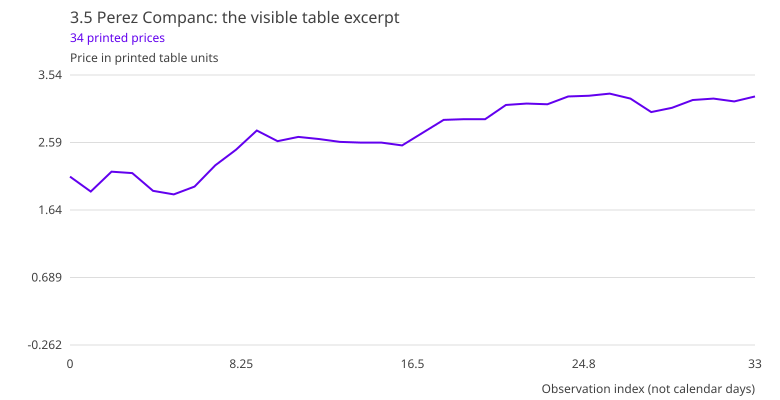

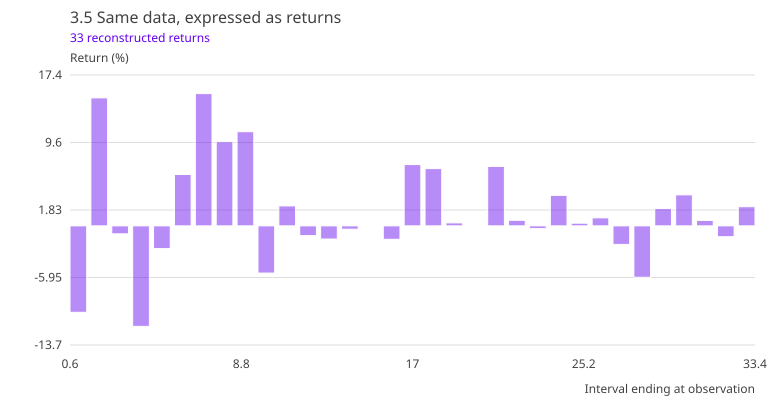

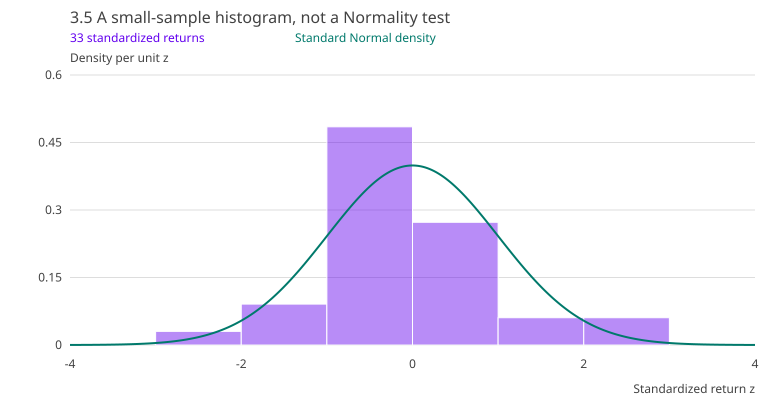

In [5]:
# ตารางรูป 3.3 หน้า 60: ราคาและผลตอบแทนที่หนังสือพิมพ์ไว้
import json
source_rows = json.loads('[{"date": "1995-03-01", "printed_price": 2.11, "book_printed_return": null, "reconstructed_return": null}, {"date": "1995-03-02", "printed_price": 1.9, "book_printed_return": -0.1, "reconstructed_return": -0.09952606635071093}, {"date": "1995-03-03", "printed_price": 2.18, "book_printed_return": 0.149906, "reconstructed_return": 0.14736842105263182}, {"date": "1995-03-06", "printed_price": 2.16, "book_printed_return": -0.01081, "reconstructed_return": -0.00917431192660556}, {"date": "1995-03-07", "printed_price": 1.91, "book_printed_return": -0.11258, "reconstructed_return": -0.11574074074074081}, {"date": "1995-03-08", "printed_price": 1.86, "book_printed_return": -0.02985, "reconstructed_return": -0.02617801047120405}, {"date": "1995-03-09", "printed_price": 1.97, "book_printed_return": 0.061538, "reconstructed_return": 0.05913978494623651}, {"date": "1995-03-10", "printed_price": 2.27, "book_printed_return": 0.15, "reconstructed_return": 0.15228426395939088}, {"date": "1995-03-13", "printed_price": 2.49, "book_printed_return": 0.099874, "reconstructed_return": 0.09691629955947145}, {"date": "1995-03-14", "printed_price": 2.76, "book_printed_return": 0.108565, "reconstructed_return": 0.10843373493975883}, {"date": "1995-03-15", "printed_price": 2.61, "book_printed_return": -0.05426, "reconstructed_return": -0.05434782608695654}, {"date": "1995-03-16", "printed_price": 2.67, "book_printed_return": 0.021858, "reconstructed_return": 0.02298850574712641}, {"date": "1995-03-17", "printed_price": 2.64, "book_printed_return": -0.0107, "reconstructed_return": -0.011235955056179692}, {"date": "1995-03-20", "printed_price": 2.6, "book_printed_return": -0.01622, "reconstructed_return": -0.015151515151515138}, {"date": "1995-03-21", "printed_price": 2.59, "book_printed_return": -0.00275, "reconstructed_return": -0.0038461538461539435}, {"date": "1995-03-22", "printed_price": 2.59, "book_printed_return": -0.00275, "reconstructed_return": 0.0}, {"date": "1995-03-23", "printed_price": 2.55, "book_printed_return": -0.01232, "reconstructed_return": -0.015444015444015413}, {"date": "1995-03-24", "printed_price": 2.73, "book_printed_return": 0.069307, "reconstructed_return": 0.07058823529411762}, {"date": "1995-03-27", "printed_price": 2.91, "book_printed_return": 0.064815, "reconstructed_return": 0.06593406593406592}, {"date": "1995-03-28", "printed_price": 2.92, "book_printed_return": 0.002899, "reconstructed_return": 0.0034364261168384758}, {"date": "1995-03-29", "printed_price": 2.92, "book_printed_return": 0.0, "reconstructed_return": 0.0}, {"date": "1995-03-30", "printed_price": 3.12, "book_printed_return": 0.069364, "reconstructed_return": 0.06849315068493156}, {"date": "1995-03-31", "printed_price": 3.14, "book_printed_return": 0.005405, "reconstructed_return": 0.0064102564102563875}, {"date": "1995-04-03", "printed_price": 3.13, "book_printed_return": -0.00269, "reconstructed_return": -0.0031847133757962887}, {"date": "1995-04-04", "printed_price": 3.24, "book_printed_return": 0.037736, "reconstructed_return": 0.03514376996805124}, {"date": "1995-04-05", "printed_price": 3.25, "book_printed_return": 0.002597, "reconstructed_return": 0.0030864197530864335}, {"date": "1995-04-06", "printed_price": 3.28, "book_printed_return": 0.007772, "reconstructed_return": 0.009230769230769154}, {"date": "1995-04-07", "printed_price": 3.21, "book_printed_return": -0.02057, "reconstructed_return": -0.021341463414634054}, {"date": "1995-04-10", "printed_price": 3.02, "book_printed_return": -0.06037, "reconstructed_return": -0.05919003115264798}, {"date": "1995-04-11", "printed_price": 3.08, "book_printed_return": 0.019553, "reconstructed_return": 0.019867549668874274}, {"date": "1995-04-12", "printed_price": 3.19, "book_printed_return": 0.035616, "reconstructed_return": 0.03571428571428559}, {"date": "1995-04-17", "printed_price": 3.21, "book_printed_return": 0.007936, "reconstructed_return": 0.006269592476489061}, {"date": "1995-04-18", "printed_price": 3.17, "book_printed_return": -0.01312, "reconstructed_return": -0.012461059190031154}, {"date": "1995-04-19", "printed_price": 3.24, "book_printed_return": 0.021277, "reconstructed_return": 0.02208201892744488}]')
dates = [r["date"] for r in source_rows]
prices = np.array([r["printed_price"] for r in source_rows])
returns = prices[1:]/prices[:-1]-1
assert len(prices)==34 and len(returns)==33
print(f"ตารางย่อย {dates[0]} ถึง {dates[-1]}: {len(prices)} ราคา / {len(returns)} ผลตอบแทน")
print(f"ผลตอบแทนแรกคำนวณจากราคาปัดเศษ: {returns[0]:.6f}")
print(f"คอลัมน์เดิมในหนังสือ: {source_rows[1]['book_printed_return']:.6f}")
print(f"เฉพาะตารางย่อย: mean={returns.mean():.6f}, sample SD={returns.std(ddof=1):.6f}")
print("สถิติอนุกรมเต็มที่หนังสือรายงาน: mean=0.002916, SD=0.024521 (ไม่ได้คำนวณจาก 34 แถวนี้)")
display(chart([dict(x=np.arange(34),y=prices,label="34 printed prices",color="#6200ee")], "3.5 Perez Companc: the visible table excerpt", "Observation index (not calendar days)", "Price in printed table units"))
display(chart([dict(x=np.arange(1,34)-.4,y=returns*100,bar_width=.8,label="33 reconstructed returns",color="#6200ee")], "3.5 Same data, expressed as returns", "Interval ending at observation", "Return (%)"))
z = (returns-returns.mean())/returns.std(ddof=1)
counts, edges = np.histogram(z, bins=8, range=(-4,4))
width = edges[1]-edges[0]
density = counts/(len(z)*width)
x = np.linspace(-4,4,300)
assert np.isclose(np.sum(density*width),1)
assert np.isclose(z.mean(),0) and np.isclose(z.std(ddof=1),1)
display(chart([dict(x=edges[:-1],y=density,bar_width=width,label="33 standardized returns",color="#6200ee"),dict(x=x,y=np.exp(-x*x/2)/np.sqrt(2*np.pi),label="Standard Normal density",color="#00796b")], "3.5 A small-sample histogram, not a Normality test", "Standardized return z", "Density per unit z", (0,.6)))


## มาตราส่วนของเวลา

ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานที่เพิ่งประมาณได้เป็นค่าของผลตอบแทนในช่วงเวลาที่เราใช้เก็บข้อมูล หากเปลี่ยนจากรายวันเป็นรายชั่วโมงหรือรายสัปดาห์ ค่าสองตัวนี้จะเปลี่ยนตามอย่างไร?

ให้ δt แทนความยาวของช่วงเวลา ค่าเฉลี่ยของผลตอบแทนช่วงสั้นแปรตามความยาวของช่วงเวลา เราจึงเขียน

$$
\text{mean}=\mu\,\delta t.
$$

μ เป็นค่าคงที่ในแบบจำลองขั้นนี้ ถ้าใช้ปีเป็นหน่วยเวลา และสมมติให้หนึ่งปีมี 252 วันซื้อขาย ช่วงหนึ่งวันจะเท่ากับ δt = 1/252 จากค่าเฉลี่ยรายวันของ Perez Companc ในหนังสือ:

$$
\mu=252\times0.002916=0.734832\approx73.5\%.
$$

ตัวเลขนี้คือ [drift](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#drift) ที่ [annualize](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#annualization) จากค่าเฉลี่ยในช่วงตัวอย่าง ไม่ใช่ผลตอบแทนที่รับประกัน และไม่ใช่ CAGR ที่คำนวณจากราคาต้นงวดกับปลายงวด

### เริ่มจากกรณีที่ยังไม่มีความสุ่ม

หากพักส่วนสุ่มไว้ก่อน แบบจำลองจะเป็น

$$
\frac{S_{i+1}-S_i}{S_i}=\mu\delta t,
\qquad S_{i+1}=S_i(1+\mu\delta t).
$$

เริ่มจาก S₀ เมื่อผ่านไปหนึ่ง step จะได้ S₀(1 + μδt) สอง step เป็น S₀(1 + μδt)² และเมื่อผ่านไป M step โดย T = Mδt:

$$
S_M=S_0(1+\mu\delta t)^M
 =S_0\exp\!\bigl[M\log(1+\mu\delta t)\bigr]
 \longrightarrow S_0e^{\mu T}.
$$

ลูกศรหมายถึงลิมิตเมื่อ δt เล็กลงไปหาศูนย์ โดยตรึงระยะเวลารวม T ไว้ ผลลัพธ์จึงบอกสองเรื่อง ประการแรก เมื่อไม่มีความสุ่ม ราคาจะเติบโตแบบเอ็กซ์โพเนนเชียลคล้ายเงินฝากที่ทบต้นต่อเนื่อง ประการที่สอง วิธีปรับค่าเฉลี่ยตาม δt ทำให้แบบจำลองยังมีความหมายเมื่อ time step เล็กลง

### ส่วนสุ่มต้องย่อตามรากที่สองของเวลา

สำหรับส่วนสุ่ม สิ่งที่รวมกันเมื่อช็อกแต่ละช่วงเป็นอิสระคือ **ความแปรปรวน** ไม่ใช่ส่วนเบี่ยงเบนมาตรฐาน หากมี T/δt step เราต้องให้ความแปรปรวนต่อ step มีขนาดแปรตาม δt เพื่อให้ความแปรปรวนรวมในช่วง T ไม่หายไปเป็นศูนย์หรือเพิ่มจนไม่จำกัดเมื่อย่อ time step

ดังนั้น ส่วนเบี่ยงเบนมาตรฐานต่อ step ต้องแปรตาม √δt:

$$
\text{standard deviation}=\sigma\sqrt{\delta t}.
$$

σ เป็นพารามิเตอร์ที่กำหนดขนาดความสุ่ม ยิ่ง σ มาก ผลตอบแทนยิ่งกระจายกว้าง จากตัวเลขในหนังสือ:

$$
\sigma=\sqrt{252}\times0.024521
 \approx0.389259\approx38.9\%.
$$

นำมาตราส่วนทั้งสองกลับมาใส่ในแบบจำลองผลตอบแทน เราจะได้

$$
R_i=\frac{S_{i+1}-S_i}{S_i}
 =\mu\delta t+\sigma\phi_i\sqrt{\delta t}.
\tag{3.4}
$$

หรือเขียนเป็นการเปลี่ยนแปลงของราคาโดยตรง:

$$
S_{i+1}-S_i=\mu S_i\delta t+\sigma S_i\phi_i\sqrt{\delta t}.
\tag{3.5}
$$

ด้านซ้ายคือราคาที่เปลี่ยนไปหนึ่ง step ด้านขวาคือแบบจำลองที่แยกเป็นส่วนค่าเฉลี่ยและส่วนสุ่ม เรารู้ราคาวันนี้ แต่ราคาวันถัดไปกระจายอยู่รอบค่าที่แบบจำลองกำหนด แทนที่จะมีค่าปลายทางเพียงค่าเดียว

### Drift

μ เรียกว่า drift rate, expected return หรือ growth rate ในบริบทของแบบจำลองนี้ ประมาณได้จาก

$$
\widehat\mu=\frac{1}{M\delta t}\sum_{i=1}^{M}R_i
 =\frac{\bar R}{\delta t}.
$$

โดยทั่วไปเลือกปีเป็นหน่วยเวลา จึงรายงาน μ ในรูปอัตราต่อปี พารามิเตอร์นี้ประมาณได้ยากในทางสถิติ เพราะในช่วงสั้นส่วนค่าเฉลี่ยมีขนาดเล็กและถูกความสุ่มบดบังได้ง่าย

ต้นฉบับชี้ว่า drift ที่แท้จริงของสินทรัพย์มีบทบาทน้อยในทฤษฎีกำหนดราคาออปชันแบบคลาสสิก ความยากในการประมาณมันจึงไม่ได้เป็นอุปสรรคในลักษณะเดียวกับการพยากรณ์ผลตอบแทน อย่างไรก็ตาม ในการจัดพอร์ตและในทฤษฎีนอกกรอบคลาสสิก drift อาจสำคัญมาก

### Volatility

σ เรียกว่า [volatility หรือความผันผวน](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#volatility) ประมาณได้จาก

$$
\widehat\sigma=
\sqrt{\frac{1}{(M-1)\delta t}
\sum_{i=1}^{M}(R_i-\bar R)^2}.
$$

เช่นเดียวกับ drift เรามักรายงานเป็นค่าที่ annualize แล้ว Volatility เป็นปริมาณสำคัญในทฤษฎีอนุพันธ์ แต่ก็เป็นปริมาณที่ประมาณและจำลองได้ยาก ผู้เขียนจึงกลับมาพิจารณาเรื่องนี้ซ้ำในหลายส่วนของหนังสือ

เนื่องจาก drift โตตามเวลา แต่ขนาดส่วนสุ่มโตตามรากที่สองของเวลา ผลของทั้งสองจึงต่างกันในแต่ละช่วง ในช่วงสั้น volatility มักเด่นกว่า ส่วนเมื่อมองช่วงยาว drift อาจเริ่มเห็นได้ชัดขึ้น า โดยเส้นค่าเฉลี่ยโตเป็นเส้นตรง และกรอบหนึ่งส่วนเบี่ยงเบนมาตรฐานกว้างขึ้นตาม √เวลา

**อ่านกรอบหนึ่งส่วนเบี่ยงเบนมาตรฐานให้ถูก**

ภายใต้ Normal ช่วงค่าเฉลี่ย ±1 SD ครอบคลุมความน่าจะเป็นประมาณ 68.3% ณ เวลาที่กำหนด ไม่ได้หมายความว่าเส้นทางทั้งเส้นจะอยู่ในกรอบตลอดช่วงด้วยโอกาส 68.3% และกฎ √เวลาอาศัยสมมติฐานเรื่องการพึ่งพากันและความแปรปรวนของ increments

mu=0.734832 (73.48%), sigma=0.389259 (38.93%)
  1 วัน: drift=0.2916%, shock SD=2.4521%
  5 วัน: drift=1.4580%, shock SD=5.4831%
 21 วัน: drift=6.1236%, shock SD=11.2369%
252 วัน: drift=73.4832%, shock SD=38.9259%


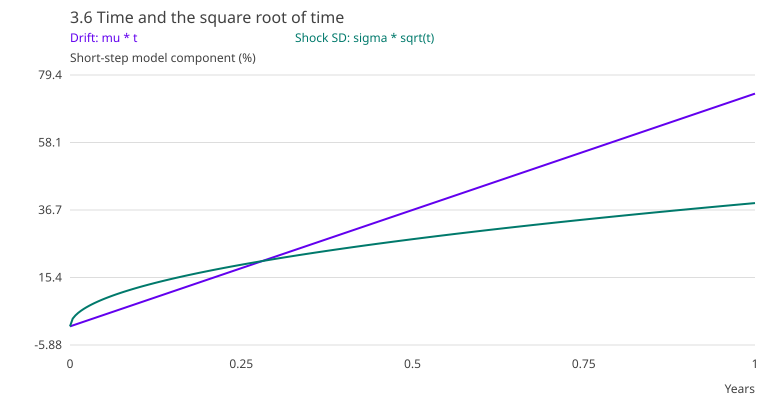

In [6]:
# Annualize สถิติอนุกรมเต็มที่หนังสือรายงาน
mu, sigma = 252*.002916, np.sqrt(252)*.024521
print(f"mu={mu:.6f} ({mu:.2%}), sigma={sigma:.6f} ({sigma:.2%})")
for days in [1,5,21,252]:
    dt = days/252
    print(f"{days:3} วัน: drift={mu*dt:.4%}, shock SD={sigma*np.sqrt(dt):.4%}")
t = np.linspace(0,1,253)
display(chart([dict(x=t,y=100*mu*t,label="Drift: mu * t",color="#6200ee"),dict(x=t,y=100*sigma*np.sqrt(t),label="Shock SD: sigma * sqrt(t)",color="#00796b")], "3.6 Time and the square root of time", "Years", "Short-step model component (%)"))
# ตัวเลขส่วนประกอบนี้ไม่ใช่ CAGR หรือขอบเขตผลตอบแทนรวม


## การประมาณความผันผวน

วิธีที่ตรงไปตรงมาที่สุดคือคำนวณส่วนเบี่ยงเบนมาตรฐานของผลตอบแทน แล้วปรับตามช่วงเวลาที่ใช้เก็บข้อมูลดังสูตรข้างต้น หาก δt เล็กพอ ผลของค่าเฉลี่ยรายช่วงอาจเล็กจนละไว้ในการประมาณได้

เมื่อช่วงเวลาสั้น ผลตอบแทนยังประมาณได้ด้วยผลต่างของลอการิทึมราคา จึงมีรูปประมาณอีกแบบว่า

$$
\widehat\sigma\approx
\sqrt{\frac{1}{(M-1)\delta t}
\sum_{i=1}^{M}\bigl[\log S(t_i)-\log S(t_{i-1})\bigr]^2}.
$$

สูตรนี้เขียนตามการประมาณในต้นฉบับ ซึ่งละค่าเฉลี่ยของ [log return](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#log-return) ไว้ หากคำนวณส่วนเบี่ยงเบนมาตรฐานของกลุ่มตัวอย่างโดยตรง ควรหักค่าเฉลี่ยก่อนตามนิยาม

```python
import numpy as np

log_returns = np.diff(np.log(prices))
annualized_vol = log_returns.std(ddof=1) * np.sqrt(252)
```

`ddof=1` ทำให้ตัวหารของ sample variance เป็น M − 1 เพื่อให้ตรงกับนิยามส่วนเบี่ยงเบนมาตรฐานของกลุ่มตัวอย่าง หากใช้ตัวหาร M จะได้ค่าต่างกัน โดยเฉพาะเมื่อข้อมูลมีจำนวนน้อย

### ความผันผวนวันนี้ต้องประมาณจากข้อมูลเมื่อวาน

ในทางปฏิบัติ volatility ไม่น่าจะคงที่ตลอดเวลา ภาวะเศรษฐกิจ ฤดูกาล และปัจจัยอื่น ๆ เปลี่ยนไป แต่หากต้องการประมาณความผันผวนวันนี้ เราต้องอาศัยข้อมูลที่เกิดขึ้นแล้ว จึงไม่มีหลักประกันว่าตัวเลขจากอดีตจะสะท้อนความผันผวนปัจจุบันได้พอดี

วิธีทั่วไปคือใช้ราคาปิดคำนวณผลตอบแทนรายวัน แล้วเลือกผลตอบแทนย้อนหลัง เช่น 10, 30 หรือ 100 ค่า มาหาความผันผวน ทุกค่าในหน้าต่างมีน้ำหนักเท่ากัน ผลตอบแทนที่รุนแรงหนึ่งวันจึงมีผลต่อค่าประมาณตลอดเวลาที่มันยังอยู่ในหน้าต่าง และผลนั้นจะหายไปทันทีเมื่อวันดังกล่าวหลุดออก

นี่คือ **plateauing effect** ที่ผู้เขียนชี้ให้เห็นในรูป 3.9 ค่าประมาณอาจค้างสูงอยู่ช่วงหนึ่งแล้วลดลง เพราะโครงสร้างของวิธีคำนวณ ไม่ใช่เพราะความผันผวนจริงของตลาดเปลี่ยนเป็นขั้นบันไดแบบนั้น

ด้วยเหตุที่ volatility สังเกตโดยตรงไม่ได้ และวิธี[หน้าต่างเลื่อน](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#rolling-window)มีข้อจำกัดนี้ เราจึงอาจต้องพิจารณาวิธีประมาณอื่น ๆ ซึ่งหนังสือกลับมาขยายความในบทที่ 49

Sample volatility ของตารางย่อยจาก log returns: 92.22%
ช็อกวันที่ 35 หลุดจากหน้าต่าง 20 วัน ในวันที่ 55


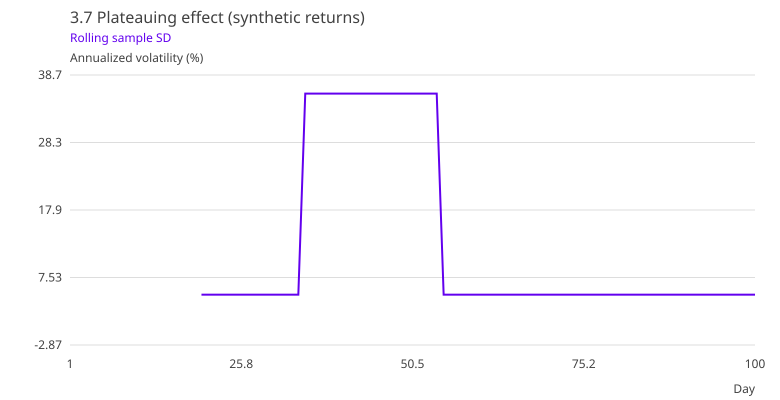

In [7]:
log_returns = np.diff(np.log(prices))
print(f"Sample volatility ของตารางย่อยจาก log returns: {log_returns.std(ddof=1)*np.sqrt(252):.2%}")
# จำลอง plateauing effect; ไม่ใช่ผลตอบแทน Perez Companc
window = 20
daily = np.array([-.003 if i%2==0 else .003 for i in range(100)])
daily[34] = -.10
rolling = np.full(100,np.nan)
for i in range(window-1,100):
    rolling[i] = daily[i-window+1:i+1].std(ddof=1)*np.sqrt(252)
exit_day = 35+window
print(f"ช็อกวันที่ 35 หลุดจากหน้าต่าง {window} วัน ในวันที่ {exit_day}")
assert rolling[exit_day-2] > rolling[exit_day-1]
display(chart([dict(x=np.arange(1,101),y=rolling*100,label="Rolling sample SD",color="#6200ee")], "3.7 Plateauing effect (synthetic returns)", "Day", "Annualized volatility (%)"))


## Wiener process

ในหัวข้อมาตราส่วนของเวลา เราแยกการเปลี่ยนแปลงออกเป็น drift ที่แปรตาม δt กับส่วนสุ่มที่มีขนาดแปรตาม √δt แล้ว ถ้าอยากอธิบายการเปลี่ยนแปลงในเวลาต่อเนื่อง เราต้องพิจารณาว่าเกิดอะไรขึ้นเมื่อช่วงเวลา δt เล็กลงไปหาศูนย์

เราจะใช้สัญลักษณ์ d เพื่อแทนการเปลี่ยนแปลงในเวลาต่อเนื่อง เช่น dS สำหรับการเปลี่ยนแปลงของราคา เทอม drift ซึ่งมี δt เป็นตัวคูณเปลี่ยนไปเป็นเทอมที่มี dt ได้ค่อนข้างตรงไปตรงมา แต่เทอมสุ่มซึ่งมี √δt ต้องระวังกว่า

เราไม่อาจจัดการมันเหมือนอนุพันธ์ธรรมดาโดยเพียงแทน δt ด้วย dt แล้วมอง √dt เป็นตัวเลขเล็ก ๆ ตัวหนึ่ง เพราะส่วนสุ่มมีค่าเฉลี่ยศูนย์ แต่มีความแปรปรวนที่สะสมตามเวลา ความละเอียดอ่อนของสองคุณสมบัตินี้คือเหตุผลที่ต้องใช้กรอบ stochastic calculus

เขียนส่วนสุ่มในเวลาต่อเนื่องด้วย **dX** ซึ่งเป็น increment ของ Wiener process แนวคิดเบื้องต้นคือ increment นี้มีค่าเฉลี่ยศูนย์และความแปรปรวน dt:

$$
\mathbb{E}[dX]=0,
\qquad \mathbb{E}[(dX)^2]=dt.
$$

Wiener process คือ process Xₜ ส่วน dX เป็นสัญลักษณ์ของ increment ในเวลาต่อเนื่อง หากเขียนสำหรับช่วงเวลาบวก Δt อย่างชัดเจน คุณสมบัติที่เกี่ยวข้องคือ

$$
X_{t+\Delta t}-X_t\sim N(0,\Delta t).
$$

โดย standard Wiener process เริ่มที่ X₀ = 0 มี increments ในช่วงที่ไม่ทับกันเป็นอิสระ และมีเส้นทางต่อเนื่อง สัญลักษณ์ Wₜ ที่อาจพบในตำราอื่นใช้แทน process ชนิดเดียวกัน

ในภาพทดลอง เมื่อเราเพิ่มจำนวน step increments แต่ละ step มีขนาดเล็กลง แต่ความแปรปรวนของผลรวมในหนึ่งปียังคงเป็นหนึ่ง ผลนี้เกิดจากการปรับขนาดด้วยรากที่สองของเวลา การเพิ่มความละเอียดจึงไม่ได้ทำให้ความสุ่มทั้งหมดหายไป

รายละเอียดของการอินทิเกรตและการคำนวณกับ Wiener process จะเป็นเนื้อหาของบทที่ 4 สำหรับตอนนี้ เป้าหมายคือเห็นว่าเรามีภาษาที่ใช้เชื่อมแบบจำลองสุ่มแบบไม่ต่อเนื่องเข้ากับเวลาต่อเนื่องแล้ว

   4 step: dt=0.250000, SD ต่อ step=0.500000, ความแปรปรวนรวมทฤษฎี=1
  64 step: dt=0.015625, SD ต่อ step=0.125000, ความแปรปรวนรวมทฤษฎี=1


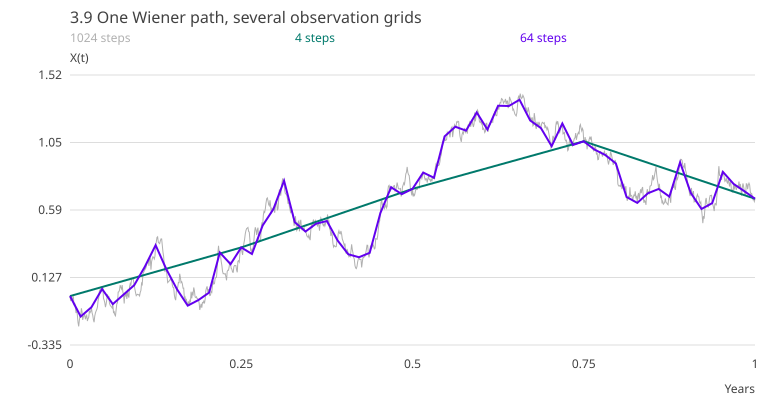

In [8]:
rng = np.random.default_rng(73)
fine = np.r_[0,np.cumsum(rng.standard_normal(1024)/np.sqrt(1024))]
series = [dict(x=np.linspace(0,1,1025),y=fine,label="1024 steps",color="#b0b0b0",stroke=1)]
for steps, color in [(4,"#00796b"),(64,"#6200ee")]:
    coarse = fine[::1024//steps]
    assert coarse[-1]==fine[-1]
    print(f"{steps:4} step: dt={1/steps:.6f}, SD ต่อ step={1/np.sqrt(steps):.6f}, ความแปรปรวนรวมทฤษฎี={steps*(1/steps):.0f}")
    series.append(dict(x=np.linspace(0,1,steps+1),y=coarse,label=f"{steps} steps",color=color))
display(chart(series,"3.9 One Wiener path, several observation grids","Years","X(t)"))
# step หยาบได้จากการรวม increments บนเส้นละเอียดเดียวกัน จุดร่วมจึงไม่เปลี่ยน


## แบบจำลองสำหรับหุ้น เงินตรา สินค้าโภคภัณฑ์ และดัชนี

นำสัญลักษณ์ Wiener process กลับมาใส่ในแบบจำลองราคา จะได้

$$
dS=\mu S\,dt+\sigma S\,dX.
\tag{3.7}
$$

นี่คือ [stochastic differential equation](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#stochastic-differential-equation) สมการแรกที่สร้างขึ้นในบท มันบรรยายการเปลี่ยนแปลงของราคาด้วยสองส่วน: การเปลี่ยนแปลงเฉลี่ย μS dt และส่วนสุ่ม σS dX ทั้งสองส่วนแปรตามระดับราคาปัจจุบัน S

แบบจำลองนี้เป็นฐานสำคัญของทฤษฎีการเงินหลายเรื่อง และเมื่อ μ, σ คงที่ เราเรียกแบบจำลองราคานี้ว่า [geometric Brownian motion หรือ GBM](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#geometric-brownian-motion) เราได้สมการนี้จากการพิจารณาผลตอบแทน รูปร่างการกระจาย และการปรับขนาดตามเวลาในหัวข้อก่อนหน้า

μS dt**ส่วน drift**

การเปลี่ยนแปลงเฉลี่ย มีขนาดแปรตาม dt

σS dX**ส่วนสุ่ม**

ค่าเฉลี่ยของ increment เป็นศูนย์ ขนาดความผันผวนแปรตาม √dt

### Monte Carlo: ถ้าอนาคตเกิดซ้ำได้หลายพันครั้ง

สมการบอกกติกาการเคลื่อนไหวของราคา แต่เส้นทางหนึ่งเส้นยังบอกภาพรวมได้ไม่มาก [Monte Carlo](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#monte-carlo) คือการใช้กติกาเดียวกันสุ่มหลายเส้นทาง แล้วรวบรวมผล เช่น ราคาปลายปีเฉลี่ย หรือสัดส่วนเส้นทางที่จบต่ำกว่าราคาเริ่มต้น

ลองเริ่มจากหุ้นราคา 100 ดอลลาร์ กำหนด μ และ σ แล้วกดสุ่ม เราไม่ได้ทายว่าเส้นไหนจะเกิดขึ้นจริง แต่กำลังดูว่า **ถ้าแบบจำลองและสมมติฐานนี้ใช้ได้ ผลลัพธ์จะกระจายอย่างไร** กดสุ่มใหม่จะเห็นคำตอบเปลี่ยนเล็กน้อย แม้ใช้สมมติฐานเดิม

การเพิ่มจำนวนรอบช่วยให้เราประมาณผลของแบบจำลองได้แม่นขึ้น แต่ไม่ได้รับประกันว่าแบบจำลองจะอธิบายตลาดจริงได้ดีขึ้น ความผิดพลาดจากการสุ่มคำนวณกับความผิดพลาดของแบบจำลองเป็นคนละเรื่องกัน

Mean=110.81, theoretical=110.52, SE=0.87
Fraction below 100: 37.3%; conditional on this model


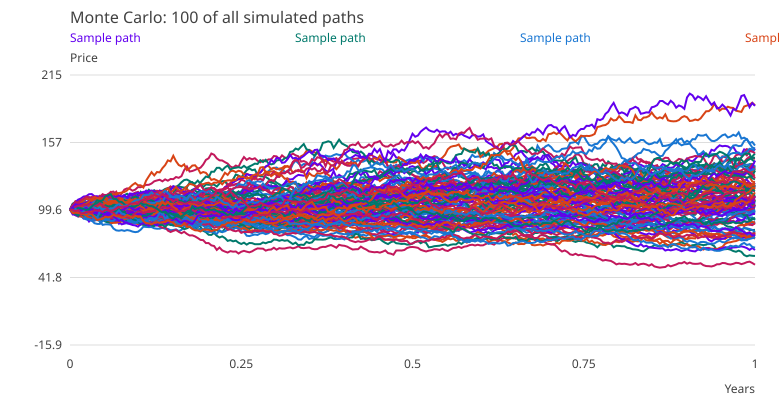

In [9]:
# Monte Carlo GBM: adjust mu, sigma and count, then rerun
mu, sigma, count, seed = .10, .25, 1000, 73
rng = np.random.default_rng(seed)
shocks = rng.standard_normal((count,252))
paths = 100*np.exp(np.cumsum((mu-.5*sigma**2)/252+sigma/np.sqrt(252)*shocks,axis=1))
paths = np.column_stack([np.full(count,100.),paths])
terminal = paths[:,-1]
print(f"Mean={terminal.mean():.2f}, theoretical={100*np.exp(mu):.2f}, SE={terminal.std(ddof=1)/np.sqrt(count):.2f}")
print(f"Fraction below 100: {np.mean(terminal<100):.1%}; conditional on this model")
display(chart([dict(x=np.linspace(0,1,253),y=p,label="Sample path",color=["#6200ee","#00796b","#1976d2","#d84315","#c2185b"][i%5]) for i,p in enumerate(paths[:100])],"Monte Carlo: 100 of all simulated paths","Years","Price"))


## Key takeaways — สิ่งที่อยากให้เก็บกลับไป

1. **เวลาวิเคราะห์การลงทุน เราควรเริ่มที่ผลตอบแทน** เพราะมันบอกการเปลี่ยนแปลงเทียบกับเงินที่ลงทุน และช่วยให้เปรียบเทียบสินทรัพย์ที่มีระดับราคาต่างกันได้

2. **ในทฤษฎีการเงิน เรามักมองผลตอบแทนเป็นตัวแปรสุ่ม** เราไม่รู้แน่นอนว่าครั้งต่อไปจะได้เท่าไร แต่สามารถศึกษาและสร้างแบบจำลองของความน่าจะเป็นได้

3. **การแจกแจงแบบ Normal เป็นสมมติฐานตั้งต้นที่มีประโยชน์ แม้ไม่สมบูรณ์** เรามักใช้ประมาณผลตอบแทนในช่วงเวลาสั้น ๆ แต่ผลตอบแทนจริงอาจมีหางหนาหรือไม่สมมาตร จึงต้องตรวจว่าสมมติฐานเหมาะกับข้อมูลแค่ไหน

4. **เราจึงสร้างแบบจำลองราคาเป็น [lognormal](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#lognormal-distribution) [random walk](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#random-walk) ได้** ในแบบจำลอง GBM ที่ μ และ σ คงที่ log-return มีการแจกแจงแบบ Normal ส่วนราคาที่เวลาใดเวลาหนึ่งในอนาคตมีการแจกแจงแบบ Lognormal และเป็นบวก ทั้งนี้ การสมมติให้ผลตอบแทนธรรมดาเป็น Normal เพียงอย่างเดียวไม่ได้ทำให้ราคาเป็น Lognormal โดยอัตโนมัติ

5. **GBM เป็นแบบจำลองราคาสินทรัพย์พื้นฐานที่ใช้กันแพร่หลาย และเขียนเป็นสมการเชิงอนุพันธ์สุ่มได้** คือ dS = μS dt + σS dX ซึ่งรวมส่วนแนวโน้มเฉลี่ยกับส่วนสุ่มไว้ด้วยกัน และเป็นจุดเริ่มต้นของการเรียน stochastic calculus ต่อไป

## ภาคทดลองเพิ่มเติม

ลองตรวจความเข้าใจด้วยคำถามสั้น ๆ แล้วปรับพารามิเตอร์เพื่อดูเส้นราคาหลายเส้นที่เป็นไปได้ภายใต้แบบจำลองเดียวกัน

ทดลองต่อ: หลายเส้นทางของ GBM และคำตอบแบบ exact

เมื่อ μ และ σ คงที่ และราคาเริ่มต้นเป็นบวก สูตรคำตอบของ GBM คือ

$$
S_t=S_0\exp\!\left[\left(\mu-\tfrac12\sigma^2\right)t+\sigma X_t\right].
$$

สูตรนี้คงราคาเป็นบวก และใช้จำลองค่าที่จุดเวลาได้ตรงตามการแจกแจงของแบบจำลอง โดยไม่ต้องใช้การประมาณราคาด้วยการบวก drift และช็อกทีละ step เทอม −σ²/2 อธิบายด้วย Itô’s lemma ในเนื้อหาที่ต่อจากบทนี้

$$
\mathbb{E}[S_t]=S_0e^{\mu t},
\qquad
\operatorname{Median}(S_t)=S_0e^{(\mu-\sigma^2/2)t}.
$$

ในพื้นที่ทดลองนี้ใช้ S₀ = 100, μ = 15%, σ = 25% และระยะเวลา 1 ปี ค่าเฉลี่ยตามทฤษฎีประมาณ 116.18 ส่วนมัธยฐานประมาณ 112.61 ความต่างระหว่างสองค่านี้เกิดจากรูปร่างการกระจายที่เบ้ไปทางขวา ไม่ใช่ข้อผิดพลาดในการจำลอง

Mean: simulation=116.26, theory=116.18
Median: simulation=112.41, theory=112.61
Standard error of sample mean=0.2105


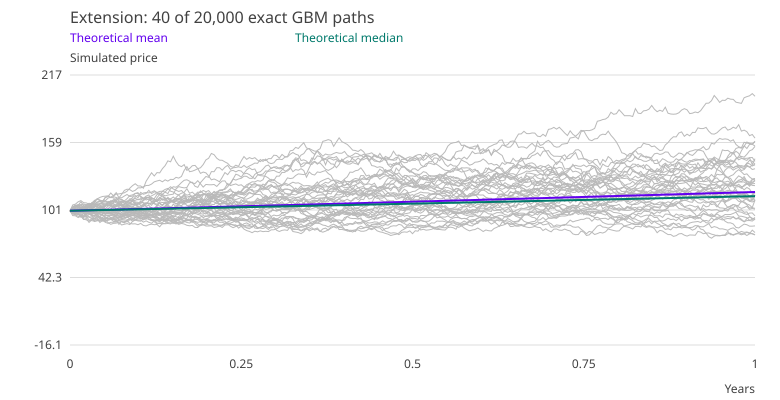

In [10]:
# ส่วนต่อยอด: exact GBM
S0, mu, sigma, years, steps, seed = 100., .15, .25, 1., 252, 73
dt = years/steps
rng = np.random.default_rng(seed)
shocks = rng.standard_normal((20000,steps))
paths = S0*np.exp(np.cumsum((mu-.5*sigma**2)*dt+sigma*np.sqrt(dt)*shocks,axis=1))
paths = np.column_stack([np.full(20000,S0),paths])
terminal = paths[:,-1]
theory_mean = S0*np.exp(mu*years)
theory_median = S0*np.exp((mu-.5*sigma**2)*years)
se = terminal.std(ddof=1)/np.sqrt(len(terminal))
print(f"Mean: simulation={terminal.mean():.2f}, theory={theory_mean:.2f}")
print(f"Median: simulation={np.median(terminal):.2f}, theory={theory_median:.2f}")
print(f"Standard error of sample mean={se:.4f}")
assert np.all(paths>0) and abs(terminal.mean()-theory_mean)<4*se
t = np.linspace(0,years,steps+1)
series = [dict(x=t,y=p,color="#b9b9b9",stroke=1) for p in paths[:40]]
series += [dict(x=t,y=S0*np.exp(mu*t),label="Theoretical mean",color="#6200ee"),dict(x=t,y=S0*np.exp((mu-.5*sigma**2)*t),label="Theoretical median",color="#00796b")]
display(chart(series,"Extension: 40 of 20,000 exact GBM paths","Years","Simulated price"))


## อ้างอิง

- Louis Bachelier (1900), [*Théorie de la spéculation*](https://www.numdam.org/item/ASENS_1900_3_17__21_0/): แนวคิดเปิดบทเรื่องความน่าจะเป็นและราคา
- Paul Wilmott (2006), *Paul Wilmott on Quantitative Finance*, 2nd ed., บท 3 หน้า 55–70: เนื้อหาที่นำมาแปลและเรียบเรียง สมการ ตัวอย่างราคาหุ้น 50/150 ที่ปรับความน่าจะเป็นเพื่อเปรียบเทียบ p กับ q และหุ้น A/B; ข้อมูล Perez Companc เป็นข้อมูลประวัติศาสตร์ตามหนังสือ
- Options Industry Council, [Options Basics](https://www.optionseducation.org/optionsoverview/options-basics): สิทธิซื้อ/ขาย ราคาใช้สิทธิ วันหมดอายุ และ premium

- Clare Wallace, Durham University, [The one-period binomial model](https://maths.dur.ac.uk/users/clare.wallace/MF/Chapter2.html): แนวคิดพอร์ตเลียนแบบและการกำหนดราคาแบบทวินาม